# Temperature Causal Analysis (No question_id)

This notebook studies the causal impact of `temperature` on three outcomes: `Agreement (µ)`, `Consistency (µ)`, and `Error Rate (µ)` using the grouped results in `output/result_without_rep_id`.

Compared with the base notebook, this version **removes `question_id` from the adjustment / moderator factors** while keeping the same rows and overall workflow.

## Design choices

- Primary treatment: `high_temperature = 1[temperature >= 1.5]`, compared against `low_temperature = 1[temperature < 1.5]`.
- Primary estimand: ATE of moving from the low-temperature regime to the high-temperature regime.
- Adjustment set / confounders: `judge_type`, `prompt_variant`, `model`.
- Moderators: `judge_type`, `prompt_variant`, `model`.
- Main estimator: cross-fitted AIPW with LightGBM nuisance models.
- Feature attribution: DAG-aware grouped SHAP on nuisance models.
- Robustness: placebo permutation test, approximate E-value, SHAP stability via bootstrap.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from graphviz import Digraph
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = Path("output/result_without_rep_id")
FIG_DIR = Path("output/causal_analysis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC_COLUMNS = ["Agreement (µ)", "Consistency (µ)", "Error Rate (µ)"]
TREATMENT_SOURCE = "temperature"
TREATMENT_COL = "high_temperature"
TREATMENT_LABEL = "High temperature (>= 1.5) vs Low temperature (< 1.5)"
COVARIATE_COLUMNS = ["question_id", "judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS = ["judge_type", "prompt_variant", "model"]

data_paths = {
    path.stem.replace("metrics_by_question_judge_prompt_temp_", ""): path
    for path in sorted(DATA_DIR.glob("metrics_by_question_judge_prompt_temp_*.jsonl"))
}
MODEL_NAMES = list(data_paths)

if not MODEL_NAMES:
    raise FileNotFoundError(f"No model files found under {DATA_DIR}")

dfs = []
for model_name, path in data_paths.items():
    if "Thinking" not in model_name and "Llama" not in model_name:
        df = pd.read_json(path, lines=True)
        df["model"] = model_name
        dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df[TREATMENT_SOURCE] = pd.to_numeric(combined_df[TREATMENT_SOURCE], errors="coerce")
combined_df[METRIC_COLUMNS] = combined_df[METRIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
combined_df["question_id"] = combined_df["question_id"].astype(str)
combined_df[TREATMENT_COL] = (combined_df[TREATMENT_SOURCE] >= 1.5).astype(int)
combined_df["temperature_bucket"] = pd.Categorical(
    np.where(combined_df[TREATMENT_COL].eq(1), "high (>=1.5)", "low (<1.5)"),
    categories=["low (<1.5)", "high (>=1.5)"],
    ordered=True,
)

for col in COVARIATE_COLUMNS:
    combined_df[col] = combined_df[col].astype("category")

ANALYSIS_COLUMNS = [TREATMENT_SOURCE, TREATMENT_COL] + COVARIATE_COLUMNS + METRIC_COLUMNS
COLUMN_MAP = pd.DataFrame(
    [
        {"Role": "Treatment", "Variable": TREATMENT_SOURCE, "Description": "Sampling temperature of the judge model."},
        {"Role": "Binary treatment", "Variable": TREATMENT_COL, "Description": TREATMENT_LABEL},
        {"Role": "Outcome", "Variable": "Agreement (µ)", "Description": "Average agreement within each grouped unit."},
        {"Role": "Outcome", "Variable": "Consistency (µ)", "Description": "Average consistency within each grouped unit."},
        {"Role": "Outcome", "Variable": "Error Rate (µ)", "Description": "Average parse / format error rate within each grouped unit."},
        {"Role": "Confounder / FE", "Variable": "question_id", "Description": "Question-level fixed effect proxy."},
        {"Role": "Confounder / Moderator", "Variable": "judge_type", "Description": "Pairwise / single-answer / reference-guided judgment mode."},
        {"Role": "Confounder / Moderator", "Variable": "prompt_variant", "Description": "Prompt strategy such as baseline or chain-of-thought."},
        {"Role": "Confounder / Moderator", "Variable": "model", "Description": "Judge model identity."},
    ]
)


def make_lgbm_regressor(random_state: int = 42) -> LGBMRegressor:
    return LGBMRegressor(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def make_lgbm_classifier(random_state: int = 42) -> LGBMClassifier:
    return LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def standardized_mean_difference_binary(x: pd.Series, t: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    t = pd.to_numeric(t, errors="coerce").fillna(0).astype(int)
    treated = x[t.eq(1)]
    control = x[t.eq(0)]
    if len(treated) == 0 or len(control) == 0:
        return np.nan
    m1 = float(treated.mean())
    m0 = float(control.mean())
    v1 = float(treated.var(ddof=1)) if len(treated) > 1 else 0.0
    v0 = float(control.var(ddof=1)) if len(control) > 1 else 0.0
    pooled = math.sqrt(max((v1 + v0) / 2.0, 1e-12))
    return abs(m1 - m0) / pooled if pooled > 0 else 0.0


def _feature_family(name: str) -> str:
    for family in COVARIATE_COLUMNS:
        if name == family or name.startswith(f"{family}_"):
            return family
    return "other"


def compute_balance_table(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    dummies = pd.get_dummies(df[COVARIATE_COLUMNS], drop_first=False, dtype=float)
    treat = df[TREATMENT_COL].astype(int)
    detail_rows = []
    for col in dummies.columns:
        detail_rows.append(
            {
                "feature": col,
                "family": _feature_family(col),
                "abs_smd": standardized_mean_difference_binary(dummies[col], treat),
            }
        )
    balance_detail = pd.DataFrame(detail_rows).sort_values("abs_smd", ascending=False).reset_index(drop=True)
    balance_summary = (
        balance_detail.groupby("family", as_index=False)["abs_smd"]
        .agg(["mean", "max", "median"])
        .reset_index()
        .rename(columns={"mean": "mean_abs_smd", "max": "max_abs_smd", "median": "median_abs_smd"})
        .sort_values("max_abs_smd", ascending=False)
        .reset_index(drop=True)
    )
    return balance_summary, balance_detail


def build_dag() -> Digraph:
    dag = Digraph()
    dag.attr(rankdir="LR")
    dag.node("Q", "question_id", shape="box")
    dag.node("J", "judge_type", shape="box")
    dag.node("P", "prompt_variant", shape="box")
    dag.node("M", "model", shape="box")
    dag.node("T", "temperature", shape="ellipse", style="filled", fillcolor="lightblue")
    dag.node("A", "Agreement (µ)", shape="ellipse")
    dag.node("C", "Consistency (µ)", shape="ellipse")
    dag.node("E", "Error Rate (µ)", shape="ellipse")
    dag.node("U", "latent prompt / parsing complexity", shape="diamond", style="dashed")

    for parent in ["Q", "J", "P", "M"]:
        dag.edge(parent, "T")
        dag.edge(parent, "A")
        dag.edge(parent, "C")
        dag.edge(parent, "E")

    dag.edge("T", "A")
    dag.edge("T", "C")
    dag.edge("T", "E")
    dag.edge("U", "A", style="dashed")
    dag.edge("U", "C", style="dashed")
    dag.edge("U", "E", style="dashed")
    return dag


def cross_fitted_aipw(
    df: pd.DataFrame,
    outcome_col: str,
    treatment_col: str = TREATMENT_COL,
    covariate_cols: list[str] = COVARIATE_COLUMNS,
    n_splits: int = 3,
    random_state: int = 42,
    n_estimators: int = 250,
    trim: float = 0.025,
    return_fold_models: bool = False,
    display_progress: bool = False,
    progress_prefix: str = "",
) -> dict:
    work = df[covariate_cols + [treatment_col, outcome_col]].dropna().copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[outcome_col]).reset_index(drop=True)

    if work[treatment_col].nunique() < 2:
        raise ValueError(f"{outcome_col}: treatment has only one level after filtering.")

    W = work[covariate_cols].copy()
    T = work[treatment_col].astype(int).to_numpy()
    Y = work[outcome_col].to_numpy()

    mu0_hat = np.zeros(len(work), dtype=float)
    mu1_hat = np.zeros(len(work), dtype=float)
    e_hat = np.zeros(len(work), dtype=float)
    fold_models = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_id, (train_idx, test_idx) in enumerate(kf.split(W), start=1):
        if display_progress:
            print(f"{progress_prefix}{outcome_col}: fitting fold {fold_id}/{n_splits}")

        W_train = W.iloc[train_idx].copy()
        W_test = W.iloc[test_idx].copy()
        T_train = T[train_idx]
        Y_train = Y[train_idx]

        prop_model = make_lgbm_classifier(random_state + fold_id)
        prop_model.set_params(n_estimators=n_estimators)
        prop_model.fit(W_train, T_train)
        e_hat[test_idx] = prop_model.predict_proba(W_test)[:, 1]

        mu0_model = make_lgbm_regressor(random_state + 100 + fold_id)
        mu1_model = make_lgbm_regressor(random_state + 200 + fold_id)
        mu0_model.set_params(n_estimators=n_estimators)
        mu1_model.set_params(n_estimators=n_estimators)

        mu0_model.fit(W_train.loc[T_train == 0], Y_train[T_train == 0])
        mu1_model.fit(W_train.loc[T_train == 1], Y_train[T_train == 1])

        mu0_hat[test_idx] = mu0_model.predict(W_test)
        mu1_hat[test_idx] = mu1_model.predict(W_test)

        fold_models.append({
            "propensity_model": prop_model,
            "mu0_model": mu0_model,
            "mu1_model": mu1_model,
        })

    e_hat = np.clip(e_hat, trim, 1.0 - trim)
    pseudo_effect = mu1_hat - mu0_hat + T * (Y - mu1_hat) / e_hat - (1 - T) * (Y - mu0_hat) / (1 - e_hat)
    ate = float(np.mean(pseudo_effect))
    se = float(np.std(pseudo_effect, ddof=1) / np.sqrt(len(pseudo_effect)))
    ci_low = ate - 1.96 * se
    ci_high = ate + 1.96 * se

    result = {
        "Outcome": outcome_col,
        "N": int(len(work)),
        "Outcome mean (treated)": float(work.loc[work[treatment_col] == 1, outcome_col].mean()),
        "Outcome mean (control)": float(work.loc[work[treatment_col] == 0, outcome_col].mean()),
        "ATE": ate,
        "SE": se,
        "CI Low": ci_low,
        "CI High": ci_high,
        "ATE (95% CI)": f"{ate:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
        "pseudo_effect": pseudo_effect,
        "analysis_df": work,
        "e_hat": e_hat,
        "mu0_hat": mu0_hat,
        "mu1_hat": mu1_hat,
    }

    if return_fold_models:
        result["fold_models"] = fold_models

    return result


def subgroup_ate(df: pd.DataFrame, outcome_col: str, subgroup_col: str) -> pd.DataFrame:
    rows = []
    for level, group in df.groupby(subgroup_col, observed=True):
        if group[TREATMENT_COL].nunique() < 2:
            continue
        res = cross_fitted_aipw(
            group,
            outcome_col=outcome_col,
            n_splits=2,
            random_state=123,
            n_estimators=150,
        )
        rows.append(
            {
                "Outcome": outcome_col,
                "Moderator": subgroup_col,
                "Level": str(level),
                "N": res["N"],
                "ATE": res["ATE"],
                "CI Low": res["CI Low"],
                "CI High": res["CI High"],
                "ATE (95% CI)": res["ATE (95% CI)"],
            }
        )
    return pd.DataFrame(rows).sort_values("ATE").reset_index(drop=True)


def fit_global_nuisance_models(df: pd.DataFrame, outcome_col: str) -> tuple[pd.DataFrame, LGBMRegressor, LGBMClassifier]:
    work = df[[TREATMENT_COL] + COVARIATE_COLUMNS + [outcome_col]].dropna().copy()
    outcome_model = make_lgbm_regressor(777)
    propensity_model = make_lgbm_classifier(888)
    outcome_model.fit(work[[TREATMENT_COL] + COVARIATE_COLUMNS], work[outcome_col])
    propensity_model.fit(work[COVARIATE_COLUMNS], work[TREATMENT_COL].astype(int))
    return work, outcome_model, propensity_model


def grouped_shap_importance(
    model,
    data: pd.DataFrame,
    feature_groups: dict[str, str],
    max_rows: int = 3000,
    random_state: int = 42,
    title: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample = data.sample(min(len(data), max_rows), random_state=random_state).copy()
    explainer = shap.TreeExplainer(model)
    explanation = explainer(sample)
    shap_values = np.asarray(explanation.values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    abs_shap = pd.DataFrame(np.abs(shap_values), columns=sample.columns)
    grouped = (
        pd.DataFrame(
            {
                "feature": sample.columns,
                "group": [feature_groups.get(col, col) for col in sample.columns],
                "mean_abs_shap": abs_shap.mean(axis=0).values,
            }
        )
        .groupby("group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    if title is not None:
        grouped["title"] = title
    return grouped, sample


def placebo_permutation_test(
    df: pd.DataFrame,
    outcome_col: str,
    n_perm: int = 10,
    random_state: int = 42,
    progress_prefix: str = "",
) -> dict:
    rng = np.random.default_rng(random_state)
    observed = cross_fitted_aipw(
        df,
        outcome_col=outcome_col,
        n_splits=2,
        random_state=random_state,
        n_estimators=120,
        display_progress=False,
    )["ATE"]
    placebo_draws = []
    for perm_idx in range(n_perm):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: placebo permutation {perm_idx + 1}/{n_perm}")
        perm_df = df.copy()
        perm_df[TREATMENT_COL] = rng.permutation(perm_df[TREATMENT_COL].to_numpy())
        perm_ate = cross_fitted_aipw(
            perm_df,
            outcome_col=outcome_col,
            n_splits=2,
            random_state=random_state + perm_idx + 1,
            n_estimators=120,
            display_progress=False,
        )["ATE"]
        placebo_draws.append(perm_ate)
    placebo_draws = np.asarray(placebo_draws, dtype=float)
    p_value = (np.sum(np.abs(placebo_draws) >= abs(observed)) + 1) / (len(placebo_draws) + 1)
    return {
        "Outcome": outcome_col,
        "Observed ATE": float(observed),
        "Placebo mean": float(np.mean(placebo_draws)),
        "Placebo std": float(np.std(placebo_draws, ddof=1)),
        "Permutation p-value": float(p_value),
        "placebo_draws": placebo_draws,
    }


def approximate_e_value(y: pd.Series, ate: float) -> dict:
    y_clean = pd.to_numeric(y, errors="coerce").dropna()
    sd = float(y_clean.std(ddof=1)) if len(y_clean) > 1 else np.nan
    if not np.isfinite(sd) or sd == 0:
        return {"Cohen's d": np.nan, "Approx RR": np.nan, "E-value": np.nan}
    d_value = ate / sd
    rr_approx = math.exp(0.91 * abs(d_value))
    e_value = rr_approx + math.sqrt(rr_approx * (rr_approx - 1.0)) if rr_approx > 1.0 else 1.0
    return {
        "Cohen's d": float(d_value),
        "Approx RR": float(rr_approx),
        "E-value": float(e_value),
    }


def shap_stability(
    df: pd.DataFrame,
    outcome_col: str,
    feature_cols: list[str],
    feature_groups: dict[str, str],
    n_boot: int = 8,
    max_rows: int = 2500,
    random_state: int = 42,
    progress_prefix: str = "",
) -> pd.DataFrame:
    base = df[feature_cols + [outcome_col]].dropna().copy()
    frames = []
    for boot_idx in range(n_boot):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: SHAP bootstrap {boot_idx + 1}/{n_boot}")
        boot = base.sample(len(base), replace=True, random_state=random_state + boot_idx)
        model = make_lgbm_regressor(random_state + 1000 + boot_idx)
        model.set_params(n_estimators=150)
        model.fit(boot[feature_cols], boot[outcome_col])
        grouped, _ = grouped_shap_importance(
            model,
            boot[feature_cols],
            feature_groups=feature_groups,
            max_rows=max_rows,
            random_state=random_state + 2000 + boot_idx,
        )
        grouped["bootstrap"] = boot_idx
        grouped["Outcome"] = outcome_col
        frames.append(grouped)
    stability = pd.concat(frames, ignore_index=True)
    summary = (
        stability.groupby(["Outcome", "group"], as_index=False)["mean_abs_shap"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "bootstrap_mean_abs_shap", "std": "bootstrap_std_abs_shap"})
        .sort_values(["Outcome", "bootstrap_mean_abs_shap"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return summary


print(f"Loaded {len(combined_df):,} rows from {len(MODEL_NAMES)} model files.")
print("Models:", MODEL_NAMES)
print("Temperature support:", sorted(combined_df[TREATMENT_SOURCE].dropna().unique().tolist()))

Loaded 54,000 rows from 5 model files.
Models: ['Llama-3.1-8B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-Next-80B-A3B-Instruct-FP8', 'Qwen3-Next-80B-A3B-Thinking-FP8', 'gemma-3-27b-it']
Temperature support: [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]


In [2]:
# Override config for the no-question_id version (keep rows unchanged).
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Force vector rendering for notebook image outputs.
set_matplotlib_formats("svg")

COVARIATE_COLUMNS[:] = ["judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS[:] = ["judge_type", "prompt_variant", "model"]

FIG_DIR = Path("output/causal_analysis_no_question_id")
FIG_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_COLUMNS = [TREATMENT_SOURCE, TREATMENT_COL] + COVARIATE_COLUMNS + METRIC_COLUMNS

for col in COVARIATE_COLUMNS:
    combined_df[col] = combined_df[col].astype("category")

COLUMN_MAP = pd.DataFrame(
    [
        {"Role": "Treatment", "Variable": TREATMENT_SOURCE, "Description": "Sampling temperature of the judge model."},
        {"Role": "Binary treatment", "Variable": TREATMENT_COL, "Description": TREATMENT_LABEL},
        {"Role": "Outcome", "Variable": "Agreement (µ)", "Description": "Average agreement within each grouped unit."},
        {"Role": "Outcome", "Variable": "Consistency (µ)", "Description": "Average consistency within each grouped unit."},
        {"Role": "Outcome", "Variable": "Error Rate (µ)", "Description": "Average parse / format error rate within each grouped unit."},
        {"Role": "Confounder / Moderator", "Variable": "judge_type", "Description": "Pairwise / single-answer / reference-guided judgment mode."},
        {"Role": "Confounder / Moderator", "Variable": "prompt_variant", "Description": "Prompt strategy such as baseline or chain-of-thought."},
        {"Role": "Confounder / Moderator", "Variable": "model", "Description": "Judge model identity."},
    ]
)

def build_dag() -> Digraph:
    dag = Digraph()
    dag.attr(rankdir="LR")
    dag.node("J", "judge_type", shape="box")
    dag.node("P", "prompt_variant", shape="box")
    dag.node("M", "model", shape="box")
    dag.node("T", "temperature", shape="ellipse", style="filled", fillcolor="lightblue")
    dag.node("A", "Agreement (µ)", shape="ellipse")
    dag.node("C", "Consistency (µ)", shape="ellipse")
    dag.node("E", "Error Rate (µ)", shape="ellipse")
    dag.node("U", "latent prompt / parsing complexity", shape="diamond", style="dashed")

    for parent in ["J", "P", "M"]:
        dag.edge(parent, "T")
        dag.edge(parent, "A")
        dag.edge(parent, "C")
        dag.edge(parent, "E")

    dag.edge("T", "A")
    dag.edge("T", "C")
    dag.edge("T", "E")
    dag.edge("U", "A", style="dashed")
    dag.edge("U", "C", style="dashed")
    dag.edge("U", "E", style="dashed")
    return dag

print("No-question_id config applied.")
print("Rows in combined_df:", len(combined_df))
print("Covariates:", COVARIATE_COLUMNS)
print("FIG_DIR:", FIG_DIR)
print("Matplotlib inline format: SVG")

No-question_id config applied.
Rows in combined_df: 54000
Covariates: ['judge_type', 'prompt_variant', 'model']
FIG_DIR: output/causal_analysis_no_question_id
Matplotlib inline format: SVG


In [3]:
display(COLUMN_MAP)

display(combined_df[ANALYSIS_COLUMNS].head())

descriptive_stats = (
    combined_df.groupby(TREATMENT_SOURCE, observed=True)[METRIC_COLUMNS]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
display(descriptive_stats)

treatment_counts = combined_df["temperature_bucket"].value_counts().rename_axis("temperature_bucket").to_frame("rows")
display(treatment_counts)

balance_summary, balance_detail = compute_balance_table(combined_df)
print("Balance summary by covariate family (absolute SMD):")
display(balance_summary.round(4))

print("Largest individual imbalances:")
display(balance_detail.head(10).round(4))

temp_by_model = (
    combined_df.groupby([TREATMENT_SOURCE, "model"], observed=True)[METRIC_COLUMNS]
    .mean()
    .reset_index()
)



,Role,Variable,Description
0,Treatment,temperature,Sampling temperature of the judge model.
1,Binary treatment,high_temperature,High temperature (>= 1.5) vs Low temperature (...
2,Outcome,Agreement (µ),Average agreement within each grouped unit.
3,Outcome,Consistency (µ),Average consistency within each grouped unit.
4,Outcome,Error Rate (µ),Average parse / format error rate within each ...
5,Confounder / Moderator,judge_type,Pairwise / single-answer / reference-guided ju...
6,Confounder / Moderator,prompt_variant,Prompt strategy such as baseline or chain-of-t...
7,Confounder / Moderator,model,Judge model identity.


,temperature,high_temperature,judge_type,prompt_variant,model,Agreement (µ),Consistency (µ),Error Rate (µ)
0,0.01,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
1,0.50,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
2,1.00,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
3,1.50,1,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
4,2.00,1,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0


Agreement (µ)                   Consistency (µ)                    \
                     mean     std  min  max            mean     std  min  max   
temperature                                                                     
0.01               0.5591  0.4775  0.0  1.0          0.9454  0.1534  0.0  1.0   
0.50               0.5565  0.4663  0.0  1.0          0.9109  0.1919  0.0  1.0   
1.00               0.5558  0.4547  0.0  1.0          0.8767  0.2217  0.0  1.0   
1.50               0.5535  0.4406  0.0  1.0          0.8394  0.2434  0.0  1.0   
2.00               0.5475  0.4254  0.0  1.0          0.7982  0.2587  0.0  1.0   
3.00               0.5184  0.3884  0.0  1.0          0.6925  0.2899  0.0  1.0   

            Error Rate (µ)                    
                      mean     std  min  max  
temperature                                   
0.01                0.0156  0.0968  0.0  1.0  
0.50                0.0184  0.0956  0.0  1.0  
1.00                0.0229  0.0971  0.0  1.0  
1.50                0.0309  0.1023  0.0  1.0  
2.00                0.0506  0.1253  0.0  1.0  
3.00                0.1249  0.1939  0.0  1.0

,rows
temperature_bucket,
low (<1.5),27000
high (>=1.5),27000


Balance summary by covariate family (absolute SMD):


,index,family,mean_abs_smd,max_abs_smd,median_abs_smd
0,0,judge_type,0.0,0.0,0.0
1,1,model,0.0,0.0,0.0
2,2,prompt_variant,0.0,0.0,0.0


Largest individual imbalances:


,feature,family,abs_smd
0,judge_type_pairwise,judge_type,0.0
1,judge_type_reference_guided,judge_type,0.0
2,judge_type_single_answer,judge_type,0.0
3,prompt_variant_baseline,prompt_variant,0.0
4,prompt_variant_cot,prompt_variant,0.0
5,model_Qwen3-30B-A3B-Instruct-2507,model,0.0
6,model_Qwen3-Next-80B-A3B-Instruct-FP8,model,0.0
7,model_gemma-3-27b-it,model,0.0


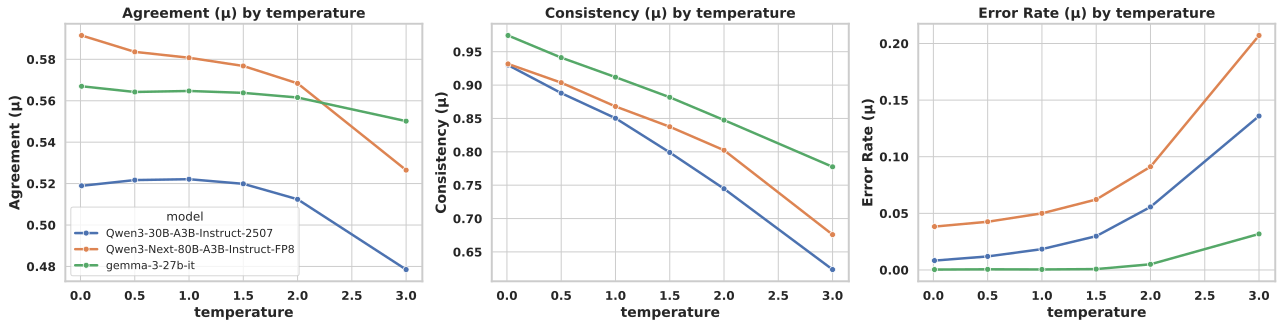

Saved: output/causal_analysis_no_question_id/temperature_metric_trends_by_model.svg


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only valid rcParams are set.
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

handles = []
labels = []

for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    lineplot = sns.lineplot(
        data=temp_by_model,
        x=TREATMENT_SOURCE,
        y=outcome_col,
        hue="model",
        marker="o",
        linewidth=2.5,
        ax=ax,
    )
    ax.set_title(f"{outcome_col} by temperature", fontsize=14, fontweight='bold')
    ax.set_xlabel("temperature", fontsize=14, fontweight='bold')
    ax.set_ylabel(outcome_col, fontsize=14, fontweight='bold')

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    if ax is axes[0]:
        handles, labels = ax.get_legend_handles_labels()
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
trend_path = FIG_DIR / "temperature_metric_trends_by_model.svg"
fig.savefig(trend_path, format="svg", bbox_inches="tight")
plt.show()
print("Saved:", trend_path)

In [5]:
# display(Markdown("## 1. Introduction\nPrimary causal question: what is the average treatment effect of moving from the low-temperature regime to the high-temperature regime on each metric?"))
# display(Markdown("## 3. Identification and ATE Estimation\nWe assume conditional unconfoundedness after adjusting for `judge_type`, `prompt_variant`, and `model`, with the same variables also treated as moderators in subgroup analysis (no `question_id` adjustment in this notebook)."))

# dag = build_dag()
# display(dag)
# try:
#     dag_path = FIG_DIR / "temperature_causal_dag"
#     dag.render(dag_path.as_posix(), format="svg", cleanup=True)
#     print("Saved:", dag_path.with_suffix(".svg"))
# except Exception as exc:
#     print("DAG render skipped:", repr(exc))

aipw_results = {}
ate_rows = []
for outcome_col in METRIC_COLUMNS:
    result = cross_fitted_aipw(
        combined_df,
        outcome_col=outcome_col,
        n_splits=3,
        random_state=42,
        n_estimators=200,
        display_progress=True,
        progress_prefix="[AIPW] ",
    )
    aipw_results[outcome_col] = result
    ate_rows.append(
        {
            "Outcome": outcome_col,
            "N": result["N"],
            "Outcome mean (control)": result["Outcome mean (control)"],
            "Outcome mean (treated)": result["Outcome mean (treated)"],
            "ATE": result["ATE"],
            "SE": result["SE"],
            "CI Low": result["CI Low"],
            "CI High": result["CI High"],
            "ATE (95% CI)": result["ATE (95% CI)"],
        }
    )

ate_table = pd.DataFrame(ate_rows)
ate_table = ate_table.round(2)
display(ate_table)
ate_path = FIG_DIR / "aipw_ate_results.csv"
ate_table.to_csv(ate_path, index=False)
print("Saved:", ate_path)

moderator_results = {}
for moderator in MODERATOR_COLUMNS:
    frames = []
    for outcome_col in METRIC_COLUMNS:
        subgroup_table = subgroup_ate(combined_df, outcome_col=outcome_col, subgroup_col=moderator)
        frames.append(subgroup_table)
    moderator_results[moderator] = pd.concat(frames, ignore_index=True)
    moderator_results[moderator] = moderator_results[moderator].round(2)

    print(f"Moderator summary: {moderator}")
    display(moderator_results[moderator].head(12))
    moderator_path = FIG_DIR / f"moderator_ate_{moderator}.csv"
    moderator_results[moderator].to_csv(moderator_path, index=False)
    print("Saved:", moderator_path)

# for moderator in MODERATOR_COLUMNS:
#     moderator_plot_df = moderator_results[moderator].copy()
#     fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)

#     for ax, outcome_col in zip(axes, METRIC_COLUMNS):
#         plot_df = moderator_plot_df.loc[moderator_plot_df["Outcome"] == outcome_col].copy()
#         plot_df = plot_df.sort_values("ATE", ascending=False)

#         ax.barh(plot_df["Level"], plot_df["ATE"], color="#4c72b0")
#         ax.axvline(0.0, color="black", linestyle="--", linewidth=1)

#         ax.set_title(
#             f"Moderator ATE by {moderator}\n{outcome_col}",
#             fontsize=14,
#             fontweight='bold',
#         )
#         ax.set_xlabel(
#             "ATE: high temp - low temp",
#             fontsize=14,
#             fontweight='bold',
#         )

#         for label in ax.get_xticklabels():
#             label.set_fontweight('bold')
#         for label in ax.get_yticklabels():
#             label.set_fontweight('bold')

#     plt.tight_layout()
#     moderator_fig_path = FIG_DIR / f"moderator_ate_by_{moderator}.svg"
#     fig.savefig(moderator_fig_path, format="svg", bbox_inches="tight")

#     if moderator == "model":
#         legacy_model_fig_path = FIG_DIR / "moderator_ate_by_model.svg"
#         fig.savefig(legacy_model_fig_path, format="svg", bbox_inches="tight")
#         print("Saved:", legacy_model_fig_path)

#     plt.show()
#     print("Saved:", moderator_fig_path)

# CATE forest plot using subgroup-level ATE estimates and 95% CI.
# display(Markdown("### CATE Forest Plot (All Moderators)"))

# fig, axes = plt.subplots(len(MODERATOR_COLUMNS), len(METRIC_COLUMNS), figsize=(18, 10), sharex=False, sharey=False)
# if len(MODERATOR_COLUMNS) == 1:
#     axes = np.array([axes])

# for r, moderator in enumerate(MODERATOR_COLUMNS):
#     for c, outcome_col in enumerate(METRIC_COLUMNS):
#         ax = axes[r, c]
#         plot_df = moderator_results[moderator].loc[
#             moderator_results[moderator]["Outcome"] == outcome_col,
#             ["Level", "ATE", "CI Low", "CI High"],
#         ].copy()

#         if plot_df.empty:
#             ax.set_visible(False)
#             continue

#         plot_df = plot_df.sort_values("ATE", ascending=True).reset_index(drop=True)
#         ate = pd.to_numeric(plot_df["ATE"], errors="coerce").to_numpy()
#         ci_low = pd.to_numeric(plot_df["CI Low"], errors="coerce").to_numpy()
#         ci_high = pd.to_numeric(plot_df["CI High"], errors="coerce").to_numpy()

#         y_pos = np.arange(len(plot_df))
#         lower = np.clip(ate - ci_low, a_min=0.0, a_max=None)
#         upper = np.clip(ci_high - ate, a_min=0.0, a_max=None)

#         ax.errorbar(
#             ate,
#             y_pos,
#             xerr=np.vstack([lower, upper]),
#             fmt="o",
#             color="#1f77b4",
#             ecolor="#4c72b0",
#             capsize=4,
#             elinewidth=1.5,
#             markersize=5,
#         )
#         ax.axvline(0.0, color="black", linestyle="--", linewidth=1)

#         ax.set_yticks(y_pos)
#         ax.set_yticklabels(plot_df["Level"])
#         ax.set_title(f"CATE Forest | {moderator}\n{outcome_col}", fontsize=12, fontweight='bold')
#         if r == len(MODERATOR_COLUMNS) - 1:
#             ax.set_xlabel("ATE (95% CI)", fontsize=11, fontweight='bold')

#         for label in ax.get_xticklabels():
#             label.set_fontweight('bold')
#         for label in ax.get_yticklabels():
#             label.set_fontweight('bold')
        

[AIPW] Agreement (µ): fitting fold 1/3
[AIPW] Agreement (µ): fitting fold 2/3
[AIPW] Agreement (µ): fitting fold 3/3
[AIPW] Consistency (µ): fitting fold 1/3
[AIPW] Consistency (µ): fitting fold 2/3
[AIPW] Consistency (µ): fitting fold 3/3
[AIPW] Error Rate (µ): fitting fold 1/3
[AIPW] Error Rate (µ): fitting fold 2/3
[AIPW] Error Rate (µ): fitting fold 3/3


,Outcome,N,Outcome mean (control),Outcome mean (treated),ATE,SE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),53920,0.56,0.54,-0.02,0.0,-0.02,-0.01,"-0.0171 [-0.0246, -0.0097]"
1,Consistency (µ),53807,0.91,0.78,-0.13,0.0,-0.14,-0.13,"-0.1342 [-0.1380, -0.1304]"
2,Error Rate (µ),54000,0.02,0.07,0.05,0.0,0.05,0.05,"0.0497 [0.0478, 0.0516]"


Saved: output/causal_analysis_no_question_id/aipw_ate_results.csv
Moderator summary: judge_type


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),judge_type,reference_guided,17991,-0.03,-0.04,-0.02,"-0.0309 [-0.0437, -0.0180]"
1,Agreement (µ),judge_type,pairwise,17975,-0.01,-0.03,0.00,"-0.0131 [-0.0266, 0.0004]"
2,Agreement (µ),judge_type,single_answer,17954,-0.01,-0.02,0.00,"-0.0086 [-0.0208, 0.0037]"
3,Consistency (µ),judge_type,single_answer,17908,-0.16,-0.17,-0.15,"-0.1611 [-0.1681, -0.1540]"
4,Consistency (µ),judge_type,reference_guided,17972,-0.14,-0.14,-0.13,"-0.1382 [-0.1450, -0.1313]"
5,Consistency (µ),judge_type,pairwise,17927,-0.10,-0.11,-0.10,"-0.1032 [-0.1090, -0.0975]"
6,Error Rate (µ),judge_type,single_answer,18000,0.03,0.02,0.03,"0.0263 [0.0232, 0.0293]"
7,Error Rate (µ),judge_type,pairwise,18000,0.06,0.05,0.06,"0.0551 [0.0516, 0.0585]"
8,Error Rate (µ),judge_type,reference_guided,18000,0.07,0.07,0.07,"0.0685 [0.0651, 0.0719]"


Saved: output/causal_analysis_no_question_id/moderator_ate_judge_type.csv
Moderator summary: prompt_variant


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),prompt_variant,cot,26920,-0.03,-0.04,-0.02,"-0.0289 [-0.0391, -0.0187]"
1,Agreement (µ),prompt_variant,baseline,27000,-0.01,-0.02,0.01,"-0.0055 [-0.0163, 0.0053]"
2,Consistency (µ),prompt_variant,cot,26807,-0.14,-0.15,-0.14,"-0.1410 [-0.1468, -0.1352]"
3,Consistency (µ),prompt_variant,baseline,27000,-0.13,-0.13,-0.12,"-0.1273 [-0.1322, -0.1225]"
4,Error Rate (µ),prompt_variant,baseline,27000,0.01,0.01,0.01,"0.0133 [0.0124, 0.0142]"
5,Error Rate (µ),prompt_variant,cot,27000,0.09,0.08,0.09,"0.0864 [0.0828, 0.0901]"


Saved: output/causal_analysis_no_question_id/moderator_ate_prompt_variant.csv
Moderator summary: model


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17929,-0.03,-0.04,-0.01,"-0.0277 [-0.0405, -0.0149]"
1,Agreement (µ),model,Qwen3-30B-A3B-Instruct-2507,17993,-0.02,-0.03,-0.00,"-0.0172 [-0.0297, -0.0048]"
2,Agreement (µ),model,gemma-3-27b-it,17998,-0.01,-0.02,0.01,"-0.0062 [-0.0196, 0.0072]"
3,Consistency (µ),model,Qwen3-30B-A3B-Instruct-2507,17982,-0.17,-0.17,-0.16,"-0.1673 [-0.1743, -0.1604]"
4,Consistency (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17828,-0.13,-0.14,-0.12,"-0.1288 [-0.1357, -0.1219]"
5,Consistency (µ),model,gemma-3-27b-it,17997,-0.11,-0.11,-0.10,"-0.1068 [-0.1125, -0.1011]"
6,Error Rate (µ),model,gemma-3-27b-it,18000,0.01,0.01,0.01,"0.0121 [0.0110, 0.0131]"
7,Error Rate (µ),model,Qwen3-30B-A3B-Instruct-2507,18000,0.06,0.06,0.06,"0.0610 [0.0580, 0.0639]"
8,Error Rate (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,18000,0.08,0.07,0.08,"0.0765 [0.0717, 0.0812]"


Saved: output/causal_analysis_no_question_id/moderator_ate_model.csv


Generating combined moderator box plots, temperature trends, and SHAP beeswarm plots...
For ROW 1: temperature trends by model.
For ROW 2: traditional boxplots by moderator.
For ROW 3: SHAP Beeswarm plots.


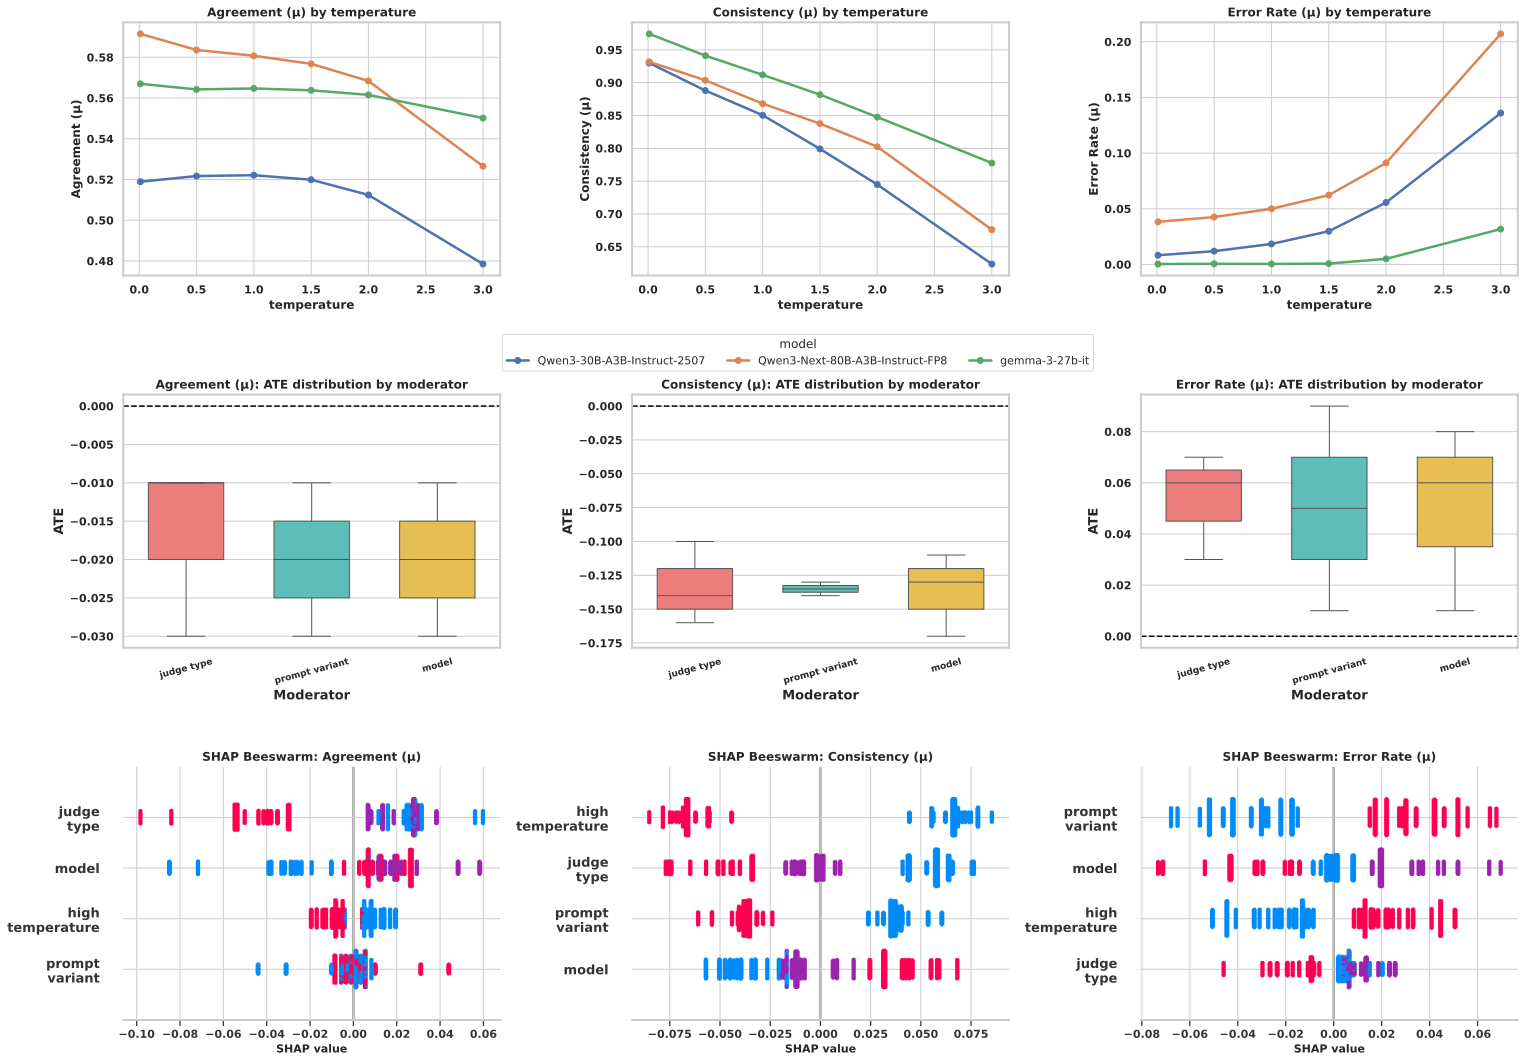

Saved: output/causal_analysis_no_question_id/ate_boxplot_temperature_trends_shap_3x3.pdf


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import numpy as np
import pandas as pd
import shap

# Only valid rcParams are set.
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["lines.linewidth"] = 2.5
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.labelweight"] = "bold"

all_moderator_df = pd.concat(moderator_results.values(), ignore_index=True)
all_moderator_df["Moderator"] = np.repeat(
    MODERATOR_COLUMNS,
    [len(moderator_results[m]) for m in MODERATOR_COLUMNS],
)

# Define bright color palette for traditional box plot.
bright_palette = ["#FF6B6B", "#4ECDC4", "#FFC93C"]

fig, axes = plt.subplots(
    3,
    len(METRIC_COLUMNS),
    figsize=(25, 18),
    sharex=False,
    sharey=False,
    gridspec_kw={"hspace": 0.47, "wspace": 0.35},
)

if len(METRIC_COLUMNS) == 1:
    axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

print("Generating combined moderator box plots, temperature trends, and SHAP beeswarm plots...")
print("For ROW 1: temperature trends by model.")
# Row 1: temperature trends by model (only mean lines, no shading).
temp_agg = combined_df.groupby([TREATMENT_SOURCE, "model"], observed=True)[METRIC_COLUMNS].agg(["mean"]).reset_index()
temp_agg.columns = ["_".join(col).strip("_") for col in temp_agg.columns.values]

for col_idx, outcome_col in enumerate(METRIC_COLUMNS):
    ax = axes[0, col_idx]

    outcome_mean_col = f"{outcome_col}_mean"
    plot_data = temp_agg[[TREATMENT_SOURCE, "model", outcome_mean_col]].copy()
    plot_data = plot_data.rename(columns={outcome_mean_col: "mean"})

    for model in sorted(plot_data["model"].unique()):
        model_data = plot_data.loc[plot_data["model"] == model].sort_values(TREATMENT_SOURCE)
        temp_vals = model_data[TREATMENT_SOURCE].values
        mean_vals = model_data["mean"].values
        ax.plot(temp_vals, mean_vals, marker="o", linewidth=2.5, label=model)

    ax.set_title(f"{outcome_col} by temperature", fontsize=12, fontweight="bold")
    ax.set_xlabel("temperature", fontsize=12, fontweight="bold")
    ax.set_ylabel(outcome_col, fontsize=12, fontweight="bold")

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    # 移除所有列的individual legend
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# 从第一列获取handles和labels用于shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()

# Row 2: traditional boxplots by moderator.
print("For ROW 2: traditional boxplots by moderator.")
for col_idx, outcome_col in enumerate(METRIC_COLUMNS):
    ax = axes[1, col_idx]
    plot_df = all_moderator_df.loc[all_moderator_df["Outcome"] == outcome_col].copy()

    sns.boxplot(
        data=plot_df,
        x="Moderator",
        y="ATE",
        ax=ax,
        palette=bright_palette,
        width=0.6,
        fliersize=0,
    )

    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(f"{outcome_col}: ATE distribution by moderator", fontweight="bold", fontsize=12)
    ax.set_xlabel("Moderator", fontweight="bold")
    ax.set_ylabel("ATE", fontweight="bold")
    ax.tick_params(axis="x", rotation=15)

    moderator_labels = [
        textwrap.fill(label.get_text().replace("_", " "), width=15)
        for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(moderator_labels, fontsize=9, fontweight="bold") 

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")


# Row 3: SHAP Beeswarm plots (keep original beeswarm style).
print("For ROW 3: SHAP Beeswarm plots.")
beeswarm_feature_cols = [TREATMENT_COL] + COVARIATE_COLUMNS
MAX_SHAP_ROWS = 25000

for col_idx, outcome_col in enumerate(METRIC_COLUMNS):
    ax = axes[2, col_idx]
    test_df = combined_df.sample(len(combined_df))
    nuisance_df, outcome_model, _ = fit_global_nuisance_models(test_df, outcome_col)

    model_feature_df = nuisance_df[beeswarm_feature_cols].copy()
    plot_feature_df = model_feature_df.copy()

    for col in plot_feature_df.columns:
        if str(plot_feature_df[col].dtype) in {"category", "object"}:
            plot_feature_df[col] = plot_feature_df[col].astype("category").cat.codes

    sample_idx = plot_feature_df.sample(min(len(plot_feature_df), MAX_SHAP_ROWS), random_state=2026).index
    sample_model_df = model_feature_df.loc[sample_idx]
    sample_plot_df = plot_feature_df.loc[sample_idx]

    explainer = shap.TreeExplainer(outcome_model)
    explanation = explainer(sample_model_df)
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    if values.ndim == 3:
        values = values[:, :, -1]
    if base_values.ndim > 1:
        base_values = base_values[:, -1]

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=sample_plot_df.to_numpy(),
        feature_names=list(sample_plot_df.columns),
    )

    plt.sca(ax)
    try:
        shap.plots.beeswarm(
            beeswarm_exp,
            max_display=10,
            show=False,
            color_bar=False,
            plot_size=None,
        )
    except TypeError:
        # Backward compatibility for older shap versions without these args.
        shap.plots.beeswarm(beeswarm_exp, max_display=10, show=False)
    
    # NEW: Replace '_' with '\n' in yticklabels for multiline display
    yticklabels = [label.get_text().replace('_', '\n') for label in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels)

    ax.set_title(f"SHAP Beeswarm: {outcome_col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("SHAP value", fontsize=11, fontweight="bold") 
    # ax.set_ylabel("Feature\nImpact", fontsize=8, fontweight="bold")  # 两行，更小字体

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

# Add shared legend at the bottom for Row 2 models.
if handles and labels:
    fig.legend(handles, labels, title="model", loc="center", bbox_to_anchor=(0.5, 0.625), ncol=min(4, len(labels)), fontsize=11, frameon=True)

plt.tight_layout(rect=(0, 0, 1, 1))
combined_plot_path = FIG_DIR / "ate_boxplot_temperature_trends_shap_3x3.pdf"
# fig.savefig(combined_plot_path, format="svg")
fig.savefig(combined_plot_path, format="pdf", bbox_inches="tight")
plt.show()
print("Saved:", combined_plot_path)

## 4. Shapley-based Feature Attribution
True causal SHAP is not directly available in this environment, so we report DAG-aware grouped SHAP on the nuisance models used by the doubly robust pipeline.

[SHAP] fitting nuisance models for Agreement (µ)
[SHAP] fitting nuisance models for Consistency (µ)
[SHAP] fitting nuisance models for Error Rate (µ)
Outcome-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,judge_type,0.032650,Agreement (µ),Agreement (µ)
1,model,0.023972,Agreement (µ),Agreement (µ)
2,temperature,0.009172,Agreement (µ),Agreement (µ)
3,prompt_variant,0.008113,Agreement (µ),Agreement (µ)
4,temperature,0.066985,Consistency (µ),Consistency (µ)
5,judge_type,0.040666,Consistency (µ),Consistency (µ)
6,prompt_variant,0.038564,Consistency (µ),Consistency (µ)
7,model,0.031630,Consistency (µ),Consistency (µ)
8,prompt_variant,0.037006,Error Rate (µ),Error Rate (µ)
9,model,0.026377,Error Rate (µ),Error Rate (µ)


Propensity-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,model,0.001189,Agreement (µ),Agreement (µ)
1,judge_type,0.001110,Agreement (µ),Agreement (µ)
2,prompt_variant,0.000725,Agreement (µ),Agreement (µ)
3,judge_type,0.002380,Consistency (µ),Consistency (µ)
4,model,0.002220,Consistency (µ),Consistency (µ)
5,prompt_variant,0.001096,Consistency (µ),Consistency (µ)
6,judge_type,0.000000,Error Rate (µ),Error Rate (µ)
7,model,0.000000,Error Rate (µ),Error Rate (µ)
8,prompt_variant,0.000000,Error Rate (µ),Error Rate (µ)


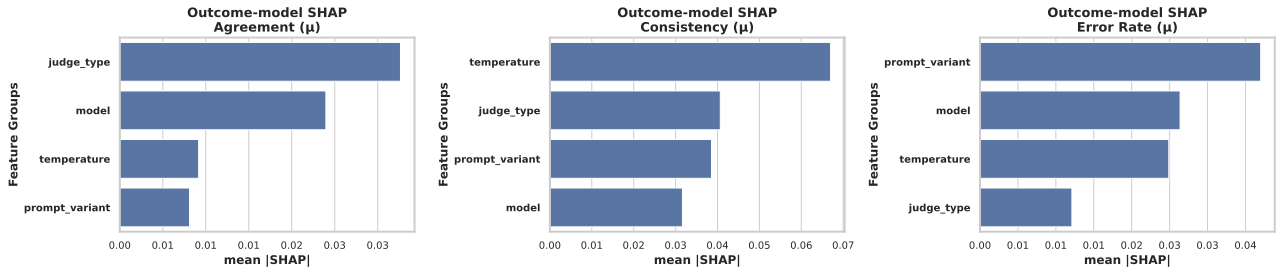

Saved: output/causal_analysis_no_question_id/outcome_model_grouped_shap.svg


## 5. Robustness Checks

[Placebo] Agreement (µ): placebo permutation 1/10
[Placebo] Agreement (µ): placebo permutation 2/10
[Placebo] Agreement (µ): placebo permutation 3/10
[Placebo] Agreement (µ): placebo permutation 4/10
[Placebo] Agreement (µ): placebo permutation 5/10
[Placebo] Agreement (µ): placebo permutation 6/10
[Placebo] Agreement (µ): placebo permutation 7/10
[Placebo] Agreement (µ): placebo permutation 8/10
[Placebo] Agreement (µ): placebo permutation 9/10
[Placebo] Agreement (µ): placebo permutation 10/10
[Placebo] Consistency (µ): placebo permutation 1/10
[Placebo] Consistency (µ): placebo permutation 2/10
[Placebo] Consistency (µ): placebo permutation 3/10
[Placebo] Consistency (µ): placebo permutation 4/10
[Placebo] Consistency (µ): placebo permutation 5/10
[Placebo] Consistency (µ): placebo permutation 6/10
[Placebo] Consistency (µ): placebo permutation 7/10
[Placebo] Consistency (µ): placebo permutation 8/10
[Placebo] Consistency (µ): placebo permutation 9/10
[Placebo] Consistency (µ): plac

,Outcome,Observed ATE,Placebo mean,Placebo std,Permutation p-value
0,Agreement (µ),-0.017151,-0.001257,0.005713,0.090909
1,Consistency (µ),-0.134302,-0.000813,0.002576,0.090909
2,Error Rate (µ),0.049809,0.000418,0.000986,0.090909


Saved: output/causal_analysis_no_question_id/placebo_permutation_results.csv


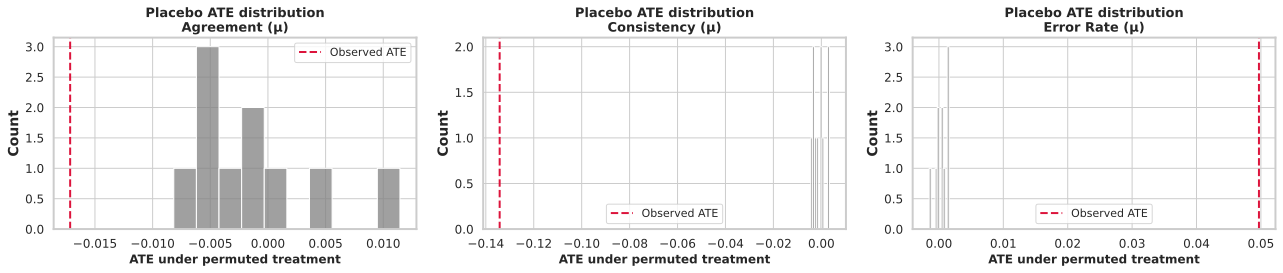

Saved: output/causal_analysis_no_question_id/placebo_permutation_histograms.svg


,Cohen's d,Approx RR,E-value,Outcome
0,-0.038683,1.035829,1.228475,Agreement (µ)
1,-0.547597,1.645943,2.677052,Consistency (µ)
2,0.384241,1.418584,2.189166,Error Rate (µ)


Saved: output/causal_analysis_no_question_id/approximate_evalues.csv
[SHAP stability] Agreement (µ): SHAP bootstrap 1/8
[SHAP stability] Agreement (µ): SHAP bootstrap 2/8
[SHAP stability] Agreement (µ): SHAP bootstrap 3/8
[SHAP stability] Agreement (µ): SHAP bootstrap 4/8
[SHAP stability] Agreement (µ): SHAP bootstrap 5/8
[SHAP stability] Agreement (µ): SHAP bootstrap 6/8
[SHAP stability] Agreement (µ): SHAP bootstrap 7/8
[SHAP stability] Agreement (µ): SHAP bootstrap 8/8
[SHAP stability] Consistency (µ): SHAP bootstrap 1/8
[SHAP stability] Consistency (µ): SHAP bootstrap 2/8
[SHAP stability] Consistency (µ): SHAP bootstrap 3/8
[SHAP stability] Consistency (µ): SHAP bootstrap 4/8
[SHAP stability] Consistency (µ): SHAP bootstrap 5/8
[SHAP stability] Consistency (µ): SHAP bootstrap 6/8
[SHAP stability] Consistency (µ): SHAP bootstrap 7/8
[SHAP stability] Consistency (µ): SHAP bootstrap 8/8
[SHAP stability] Error Rate (µ): SHAP bootstrap 1/8
[SHAP stability] Error Rate (µ): SHAP bootstrap

,index,Outcome,group,bootstrap_mean_abs_shap,bootstrap_std_abs_shap
0,0,Agreement (µ),judge_type,0.032365,0.001124
1,1,Agreement (µ),model,0.025129,0.001311
2,2,Agreement (µ),prompt_variant,0.008949,0.000550
3,3,Agreement (µ),temperature,0.008871,0.002013
4,3,Consistency (µ),temperature,0.066451,0.000574
5,0,Consistency (µ),judge_type,0.039347,0.001240
6,2,Consistency (µ),prompt_variant,0.038717,0.001291
7,1,Consistency (µ),model,0.031568,0.000584
8,2,Error Rate (µ),prompt_variant,0.037080,0.000858
9,1,Error Rate (µ),model,0.026333,0.000693


Saved: output/causal_analysis_no_question_id/shap_stability_summary.csv


## 6. Discussion

,Outcome,ATE interpretation,Top SHAP driver,Strongest model moderator,Permutation p-value,Approx E-value
0,Agreement (µ),Moving to high temperature decreases Agreement...,judge_type,Qwen3-Next-80B-A3B-Instruct-FP8,0.090909,1.228475
1,Consistency (µ),Moving to high temperature decreases Consisten...,temperature,Qwen3-30B-A3B-Instruct-2507,0.090909,2.677052
2,Error Rate (µ),Moving to high temperature increases Error Rat...,prompt_variant,Qwen3-Next-80B-A3B-Instruct-FP8,0.090909,2.189166


Saved: output/causal_analysis_no_question_id/discussion_summary.csv


## Automatically generated discussion
- **Agreement (µ)**: Moving to high temperature decreases Agreement (µ) by -0.0171 on average. Top nuisance-model SHAP driver: `judge_type`. Strongest model-level moderator: `Qwen3-Next-80B-A3B-Instruct-FP8`. Permutation p-value = **0.09**; approximate E-value = **1.23**.
- **Consistency (µ)**: Moving to high temperature decreases Consistency (µ) by -0.1342 on average. Top nuisance-model SHAP driver: `temperature`. Strongest model-level moderator: `Qwen3-30B-A3B-Instruct-2507`. Permutation p-value = **0.09**; approximate E-value = **2.68**.
- **Error Rate (µ)**: Moving to high temperature increases Error Rate (µ) by 0.0497 on average. Top nuisance-model SHAP driver: `prompt_variant`. Strongest model-level moderator: `Qwen3-Next-80B-A3B-Instruct-FP8`. Permutation p-value = **0.09**; approximate E-value = **2.19**.

In [41]:
display(Markdown("## 4. Shapley-based Feature Attribution\nTrue causal SHAP is not directly available in this environment, so we report DAG-aware grouped SHAP on the nuisance models used by the doubly robust pipeline."))

outcome_feature_groups = {
    TREATMENT_COL: "temperature",
    "question_id": "question_id",
    "judge_type": "judge_type",
    "prompt_variant": "prompt_variant",
    "model": "model",
}
propensity_feature_groups = {key: key for key in COVARIATE_COLUMNS}

outcome_shap_tables = []
propensity_shap_tables = []
for outcome_col in METRIC_COLUMNS:
    print(f"[SHAP] fitting nuisance models for {outcome_col}")
    nuisance_df, outcome_model, propensity_model = fit_global_nuisance_models(combined_df, outcome_col)

    grouped_outcome_shap, _ = grouped_shap_importance(
        outcome_model,
        nuisance_df[[TREATMENT_COL] + COVARIATE_COLUMNS],
        feature_groups=outcome_feature_groups,
        max_rows=3000,
        random_state=42,
        title=outcome_col,
    )
    grouped_outcome_shap["Outcome"] = outcome_col
    outcome_shap_tables.append(grouped_outcome_shap)

    grouped_prop_shap, _ = grouped_shap_importance(
        propensity_model,
        nuisance_df[COVARIATE_COLUMNS],
        feature_groups=propensity_feature_groups,
        max_rows=3000,
        random_state=84,
        title=outcome_col,
    )
    grouped_prop_shap["Outcome"] = outcome_col
    propensity_shap_tables.append(grouped_prop_shap)

outcome_shap_df = pd.concat(outcome_shap_tables, ignore_index=True)
propensity_shap_df = pd.concat(propensity_shap_tables, ignore_index=True)

print("Outcome-model grouped SHAP:")
display(outcome_shap_df)

print("Propensity-model grouped SHAP:")
display(propensity_shap_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].sort_values("mean_abs_shap", ascending=False)
    sns.barplot(data=plot_df, x="mean_abs_shap", y="group", ax=ax, color="#4c72b0")
    ax.set_title(f"Outcome-model SHAP\n{outcome_col}", fontsize=13, fontweight='bold')
    ax.set_xlabel("mean |SHAP|", fontweight='bold', fontsize=12)
    ax.set_ylabel("Feature Groups", fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    ax.tick_params(axis='y', labelsize=10)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.tight_layout()
outcome_shap_path = FIG_DIR / "outcome_model_grouped_shap.svg"
fig.savefig(outcome_shap_path, format="svg", bbox_inches="tight")
plt.show()
print("Saved:", outcome_shap_path)

display(Markdown("## 5. Robustness Checks"))

placebo_results = []
placebo_draw_map = {}
for idx, outcome_col in enumerate(METRIC_COLUMNS):
    placebo = placebo_permutation_test(
        combined_df,
        outcome_col=outcome_col,
        n_perm=10,
        random_state=100 + idx,
        progress_prefix="[Placebo] ",
    )
    placebo_draw_map[outcome_col] = placebo["placebo_draws"]
    placebo_results.append(
        {
            key: value
            for key, value in placebo.items()
            if key != "placebo_draws"
        }
    )

placebo_table = pd.DataFrame(placebo_results)
display(placebo_table)
placebo_path = FIG_DIR / "placebo_permutation_results.csv"
placebo_table.to_csv(placebo_path, index=False)
print("Saved:", placebo_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.histplot(placebo_draw_map[outcome_col], bins=10, color="gray", ax=ax)
    ax.axvline(aipw_results[outcome_col]["ATE"], color="crimson", linestyle="--", linewidth=2, label="Observed ATE")
    ax.set_title(f"Placebo ATE distribution\n{outcome_col}", fontsize=13, fontweight='bold')
    ax.set_xlabel("ATE under permuted treatment", fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
placebo_fig_path = FIG_DIR / "placebo_permutation_histograms.svg"
fig.savefig(placebo_fig_path, format="svg", bbox_inches="tight")
plt.show()
print("Saved:", placebo_fig_path)

evalue_rows = []
for outcome_col in METRIC_COLUMNS:
    metrics = approximate_e_value(combined_df[outcome_col], aipw_results[outcome_col]["ATE"])
    metrics["Outcome"] = outcome_col
    evalue_rows.append(metrics)

evalue_table = pd.DataFrame(evalue_rows)
display(evalue_table)
evalue_path = FIG_DIR / "approximate_evalues.csv"
evalue_table.to_csv(evalue_path, index=False)
print("Saved:", evalue_path)

shap_stability_frames = []
for outcome_col in METRIC_COLUMNS:
    stability = shap_stability(
        combined_df,
        outcome_col=outcome_col,
        feature_cols=[TREATMENT_COL] + COVARIATE_COLUMNS,
        feature_groups=outcome_feature_groups,
        n_boot=8,
        max_rows=2500,
        random_state=300,
        progress_prefix="[SHAP stability] ",
    )
    shap_stability_frames.append(stability)

shap_stability_df = pd.concat(shap_stability_frames, ignore_index=True)
display(shap_stability_df)
stability_path = FIG_DIR / "shap_stability_summary.csv"
shap_stability_df.to_csv(stability_path, index=False)
print("Saved:", stability_path)

display(Markdown("## 6. Discussion"))

discussion_rows = []
for outcome_col in METRIC_COLUMNS:
    ate_value = aipw_results[outcome_col]["ATE"]
    direction = "increases" if ate_value >= 0 else "decreases"
    top_driver = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].iloc[0]["group"]
    top_model_level = (
        moderator_results["model"]
        .loc[moderator_results["model"]["Outcome"] == outcome_col]
        .sort_values("ATE", key=lambda s: s.abs(), ascending=False)
        .iloc[0]["Level"]
    )
    discussion_rows.append(
        {
            "Outcome": outcome_col,
            "ATE interpretation": f"Moving to high temperature {direction} {outcome_col} by {ate_value:.4f} on average.",
            "Top SHAP driver": top_driver,
            "Strongest model moderator": top_model_level,
            "Permutation p-value": float(placebo_table.loc[placebo_table["Outcome"] == outcome_col, "Permutation p-value"].iloc[0]),
            "Approx E-value": float(evalue_table.loc[evalue_table["Outcome"] == outcome_col, "E-value"].iloc[0]),
        }
    )

discussion_table = pd.DataFrame(discussion_rows)
display(discussion_table)
discussion_path = FIG_DIR / "discussion_summary.csv"
discussion_table.to_csv(discussion_path, index=False)
print("Saved:", discussion_path)

summary_lines = ["## Automatically generated discussion"]
for row in discussion_table.itertuples(index=False):
    summary_lines.append(
        f"- **{row.Outcome}**: {row._1 if False else row[1]} Top nuisance-model SHAP driver: `{row[2]}`. "
        f"Strongest model-level moderator: `{row[3]}`. "
        f"Permutation p-value = **{row[4]:.2f}**; approximate E-value = **{row[5]:.2f}**."
    )
display(Markdown("\n".join(summary_lines)))

## Extra: SHAP Beeswarm

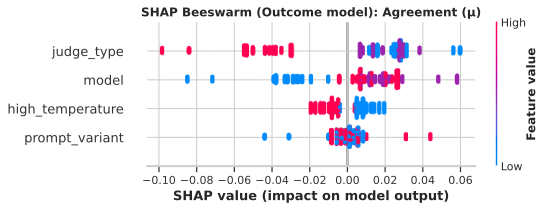

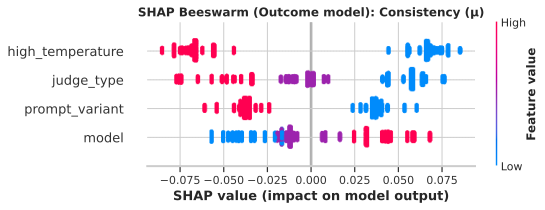

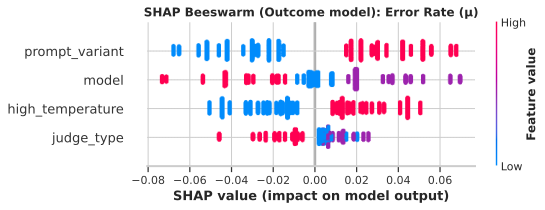

Saved beeswarm plots:
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Agreement_mu.svg
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Consistency_mu.svg
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Error_Rate_mu.svg


In [42]:
display(Markdown("## Extra: SHAP Beeswarm"))

beeswarm_paths = []
beeswarm_feature_cols = [TREATMENT_COL] + COVARIATE_COLUMNS

for outcome_col in METRIC_COLUMNS:
    nuisance_df, outcome_model, _ = fit_global_nuisance_models(combined_df, outcome_col)

    model_feature_df = nuisance_df[beeswarm_feature_cols].copy()
    plot_feature_df = model_feature_df.copy()

    for col in plot_feature_df.columns:
        if str(plot_feature_df[col].dtype) in {"category", "object"}:
            plot_feature_df[col] = plot_feature_df[col].astype("category").cat.codes

    sample_idx = plot_feature_df.sample(min(len(plot_feature_df), 3000), random_state=2026).index
    sample_model_df = model_feature_df.loc[sample_idx]
    sample_plot_df = plot_feature_df.loc[sample_idx]

    explainer = shap.TreeExplainer(outcome_model)
    explanation = explainer(sample_model_df)
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=sample_plot_df.to_numpy(),
        feature_names=list(sample_plot_df.columns),
    )

    plt.figure(figsize=(8, 5))
    shap.plots.beeswarm(beeswarm_exp, max_display=12, show=False)
    plt.title(f"SHAP Beeswarm (Outcome model): {outcome_col}", fontweight='bold')
    plt.tight_layout()

    safe_name = (
        outcome_col
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("µ", "mu")
        .replace("/", "_")
    )
    beeswarm_path = FIG_DIR / f"outcome_model_shap_beeswarm_{safe_name}.svg"
    plt.savefig(beeswarm_path, format="svg", bbox_inches="tight")
    plt.show()
    beeswarm_paths.append(beeswarm_path)

print("Saved beeswarm plots:")
for p in beeswarm_paths:
    print("-", p)

## Extra: SHAP Beeswarm (Individual Feature Attribution)

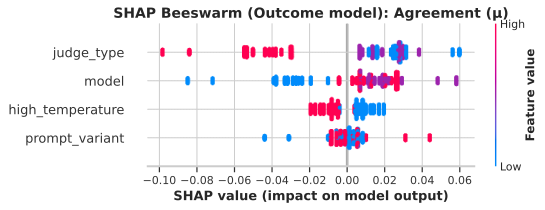

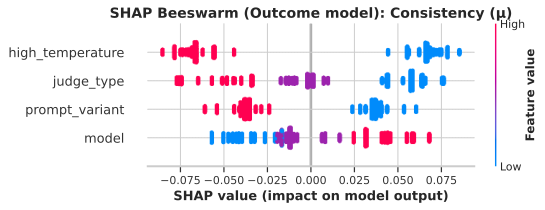

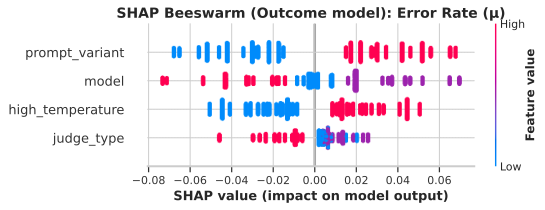

Saved SHAP Beeswarm plots:
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Agreement_mu.svg
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Consistency_mu.svg
- output/causal_analysis_no_question_id/outcome_model_shap_beeswarm_Error_Rate_mu.svg


In [33]:
display(Markdown("## Extra: SHAP Beeswarm (Individual Feature Attribution)"))

beeswarm_paths = []
beeswarm_feature_cols = [TREATMENT_COL] + COVARIATE_COLUMNS

for outcome_col in METRIC_COLUMNS:
    nuisance_df, outcome_model, _ = fit_global_nuisance_models(combined_df, outcome_col)

    model_feature_df = nuisance_df[beeswarm_feature_cols].copy()
    plot_feature_df = model_feature_df.copy()

    for col in plot_feature_df.columns:
        if str(plot_feature_df[col].dtype) in {"category", "object"}:
            plot_feature_df[col] = plot_feature_df[col].astype("category").cat.codes

    sample_idx = plot_feature_df.sample(min(len(plot_feature_df), 3000), random_state=2026).index
    sample_model_df = model_feature_df.loc[sample_idx]
    sample_plot_df = plot_feature_df.loc[sample_idx]

    explainer = shap.TreeExplainer(outcome_model)
    explanation = explainer(sample_model_df)
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=sample_plot_df.to_numpy(),
        feature_names=list(sample_plot_df.columns),
    )

    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(beeswarm_exp, max_display=12, show=False)
    plt.title(f"SHAP Beeswarm (Outcome model): {outcome_col}", fontweight='bold', fontsize=14)
    plt.tight_layout()

    safe_name = (
        outcome_col
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("µ", "mu")
        .replace("/", "_")
    )
    beeswarm_path = FIG_DIR / f"outcome_model_shap_beeswarm_{safe_name}.svg"
    plt.savefig(beeswarm_path, format="svg", bbox_inches="tight", dpi=120)
    plt.show()
    beeswarm_paths.append(beeswarm_path)

print("Saved SHAP Beeswarm plots:")
for p in beeswarm_paths:
    print("-", p)